# K Nearest Neighbors with Python

You've been given a classified data set from a company! They've hidden the feature column names but have given you the data and the target classes. 

We'll try to use KNN to create a model that directly predicts a class for a new data point based off of the features.

Let's grab it and use it!

## Import Libraries



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Get the Data

Set index_col=0 to use the first column as the index.

In [2]:
df = pd.read_csv("./Data/Classified Data",index_col=0)
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


## Standardize the Variables

Because the KNN classifier predicts the class of a given test observation by identifying the observations that are nearest to it, the scale of the variables matters. Any variables that are on a large scale will have a much larger effect on the distance between the observations, and hence on the KNN classifier, than variables that are on a small scale.

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
scaler = StandardScaler()

In [5]:
scaler.fit(df.drop('TARGET CLASS',axis=1))

StandardScaler()

In [6]:
scaled_features = scaler.transform(df.drop('TARGET CLASS',axis=1))

In [7]:
df_feat = pd.DataFrame(scaled_features, columns = df.columns[:-1])
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


## Pair Plot

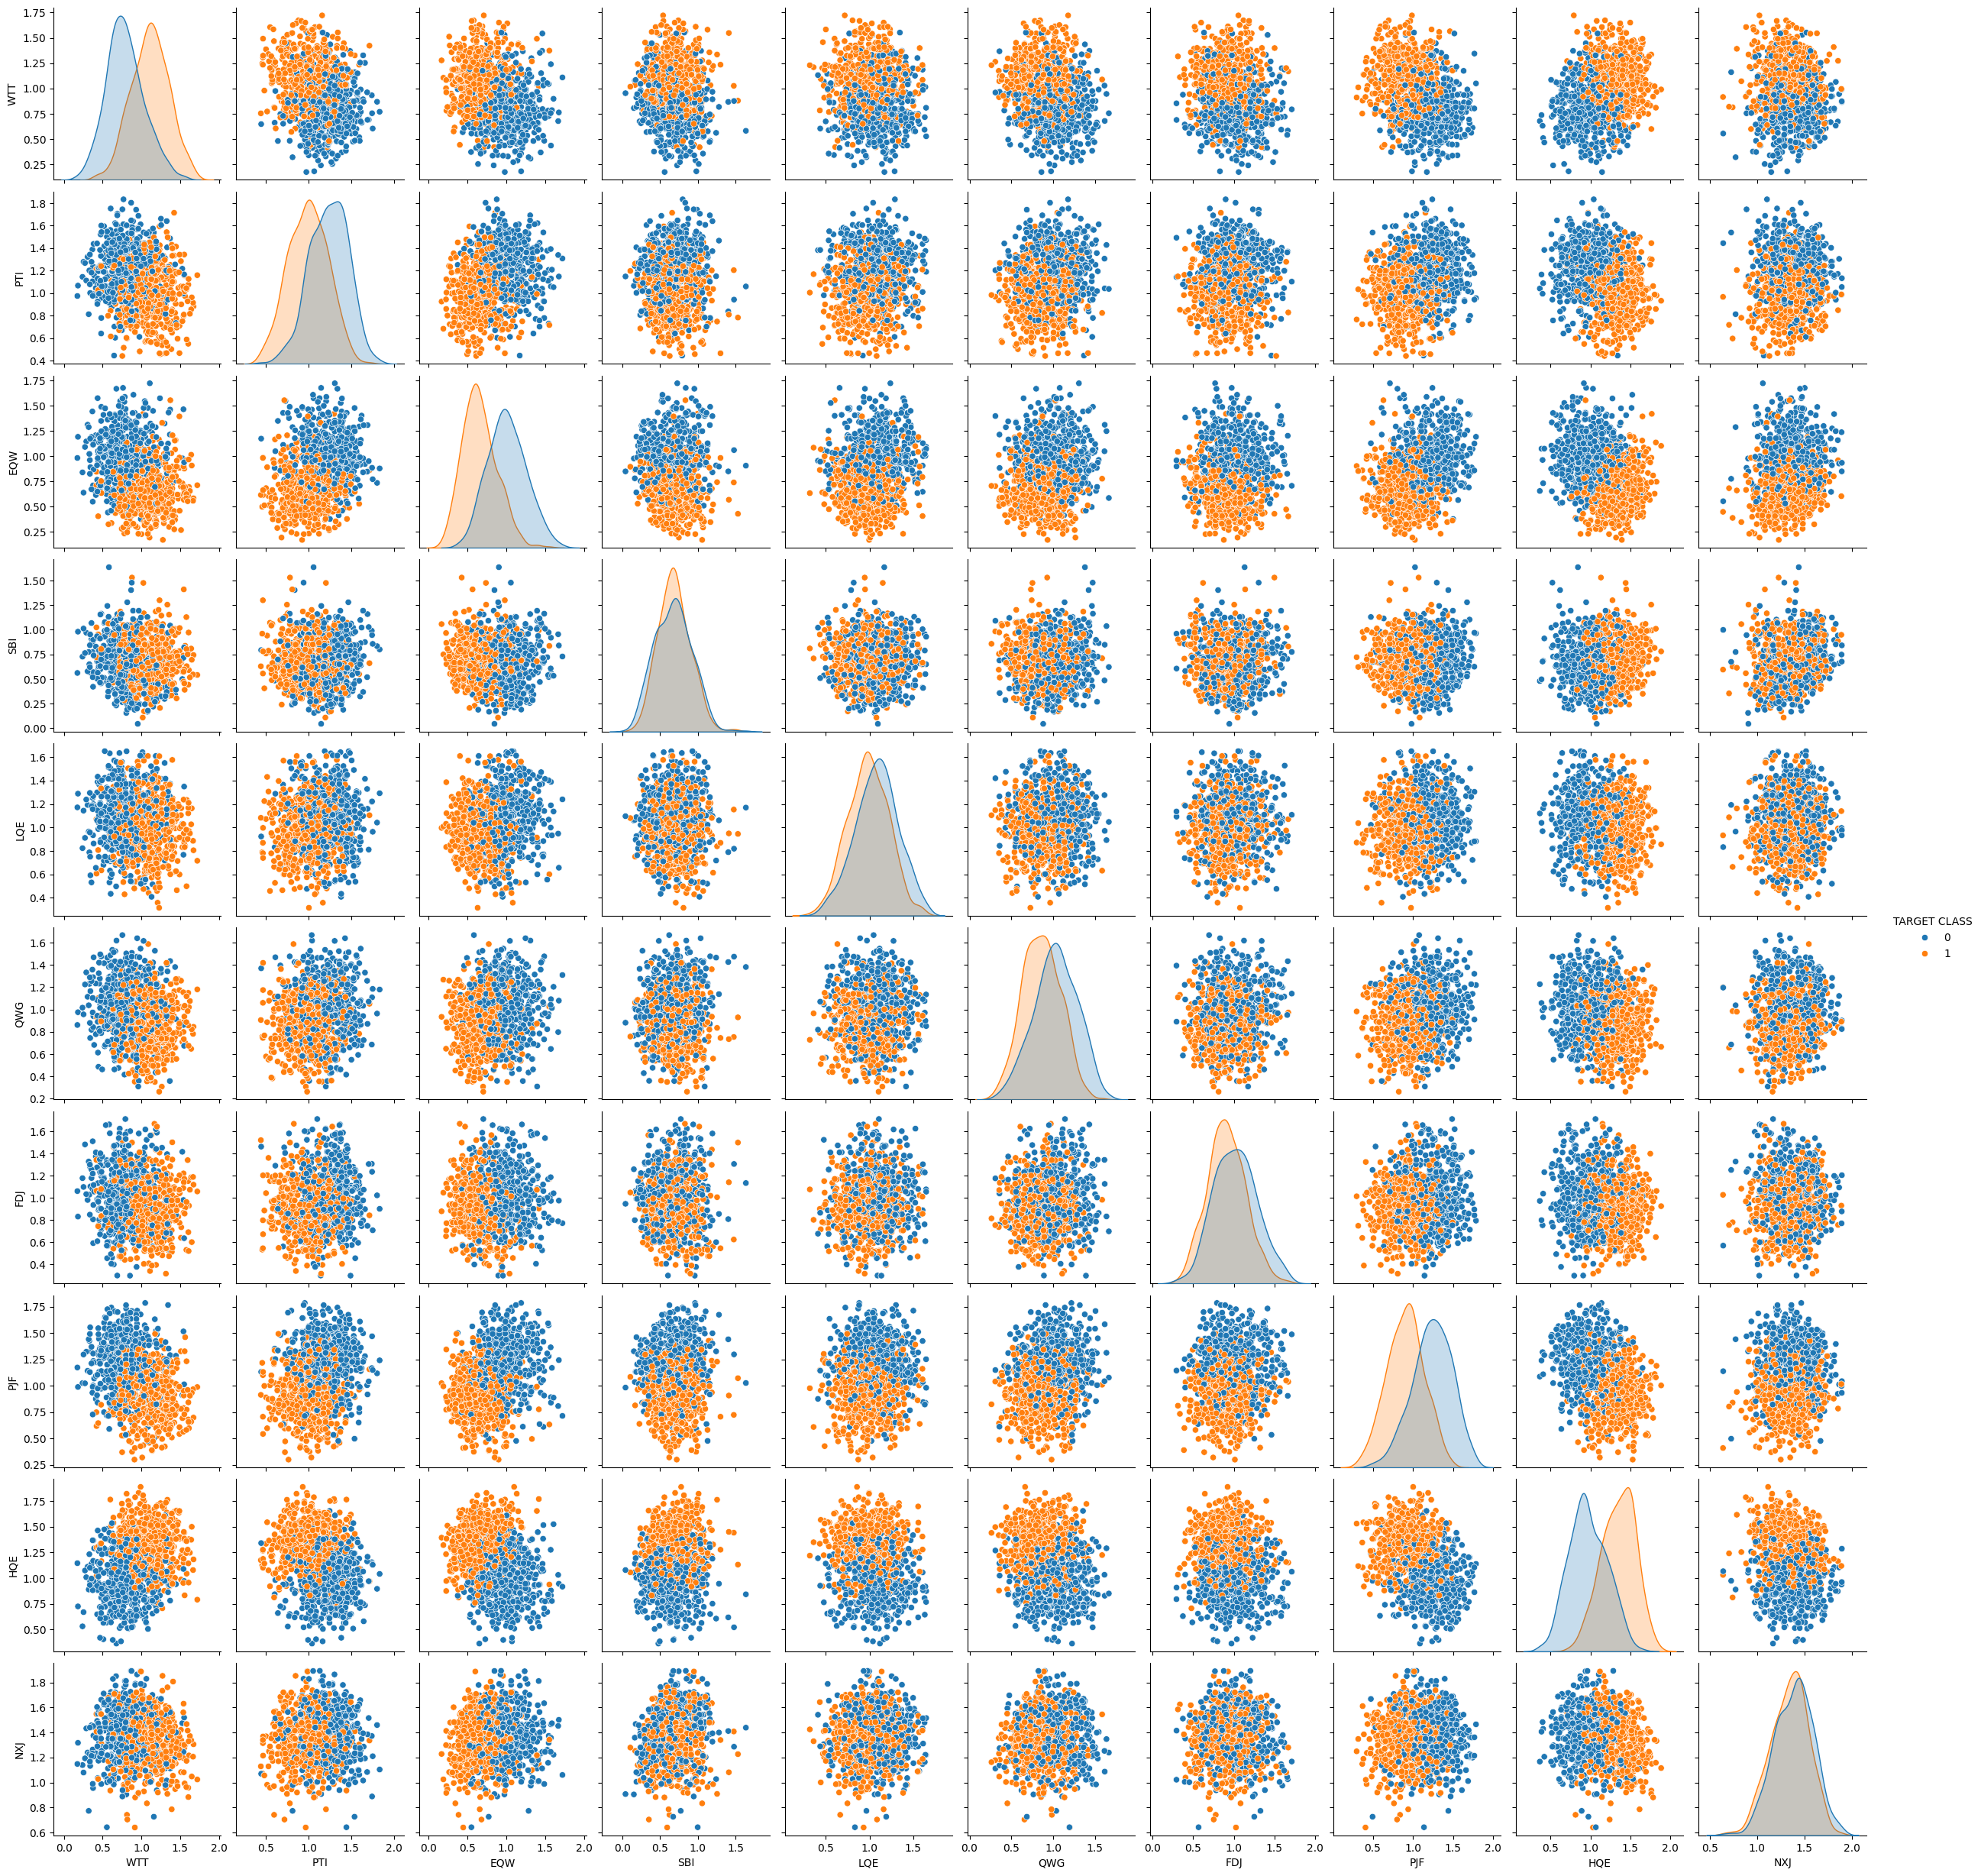

In [11]:
import seaborn as sns

sns.pairplot(df,hue='TARGET CLASS')

## Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(scaled_features, df['TARGET CLASS'],test_size=0.30, random_state = 42)

## Using KNN

Remember that we are trying to come up with a model to predict whether someone will TARGET CLASS or not. We'll start with k=1.

In [13]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
knn = KNeighborsClassifier(n_neighbors=1, metric='minkowski')

In [15]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [16]:
pred = knn.predict(X_test)

## Predictions and Evaluations

Let's evaluate our KNN model!

In [17]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score

In [18]:
print(confusion_matrix(y_test,pred))

[[134   8]
 [ 11 147]]


In [19]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       142
           1       0.95      0.93      0.94       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



## Choosing a K Value

Let's go ahead and use the elbow method to pick a good K Value:

In [29]:
accuracy_rate = []

# Will take some time
for i in range(1,40):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    score=cross_val_score(knn, df_feat, df['TARGET CLASS'], cv=10)
    accuracy_rate.append(score.mean())

print(accuracy_rate)

[0.9109999999999999, 0.909, 0.9280000000000002, 0.9339999999999999, 0.9289999999999999, 0.929, 0.9310000000000003, 0.9340000000000002, 0.9289999999999999, 0.9350000000000002, 0.9329999999999998, 0.9350000000000002, 0.937, 0.9410000000000001, 0.9390000000000001, 0.9390000000000001, 0.9349999999999999, 0.9360000000000002, 0.9360000000000002, 0.9360000000000002, 0.9339999999999999, 0.9359999999999999, 0.93, 0.933, 0.9349999999999999, 0.937, 0.9380000000000001, 0.938, 0.937, 0.9390000000000001, 0.9360000000000002, 0.943, 0.937, 0.9390000000000001, 0.9390000000000001, 0.9400000000000001, 0.9369999999999999, 0.943, 0.9410000000000001]


In [33]:
error_rate = []

# Will take some time
for i in range(1,40):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    score=cross_val_score(knn,df_feat,df['TARGET CLASS'],cv=10)
    error_rate.append(1-score.mean())

print(error_rate)

[0.08900000000000008, 0.09099999999999997, 0.07199999999999984, 0.06600000000000006, 0.07100000000000006, 0.07099999999999995, 0.06899999999999973, 0.06599999999999984, 0.07100000000000006, 0.06499999999999984, 0.06700000000000017, 0.06499999999999984, 0.06299999999999994, 0.05899999999999994, 0.06099999999999994, 0.06099999999999994, 0.06500000000000006, 0.06399999999999983, 0.06399999999999983, 0.06399999999999983, 0.06600000000000006, 0.06400000000000006, 0.06999999999999995, 0.06699999999999995, 0.06500000000000006, 0.06299999999999994, 0.061999999999999944, 0.062000000000000055, 0.06299999999999994, 0.06099999999999994, 0.06399999999999983, 0.05700000000000005, 0.06299999999999994, 0.06099999999999994, 0.06099999999999994, 0.05999999999999994, 0.06300000000000006, 0.05700000000000005, 0.05899999999999994]


In [31]:
error_rate = []

# Will take some time
for i in range(1,40):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
    
print(error_rate)

[0.06333333333333334, 0.08333333333333333, 0.056666666666666664, 0.056666666666666664, 0.056666666666666664, 0.056666666666666664, 0.06333333333333334, 0.056666666666666664, 0.056666666666666664, 0.05, 0.05, 0.04666666666666667, 0.04666666666666667, 0.04666666666666667, 0.04666666666666667, 0.04666666666666667, 0.04666666666666667, 0.05, 0.05333333333333334, 0.05333333333333334, 0.05, 0.056666666666666664, 0.056666666666666664, 0.05333333333333334, 0.06, 0.056666666666666664, 0.05333333333333334, 0.05333333333333334, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05]


Text(0, 0.5, 'Error Rate')

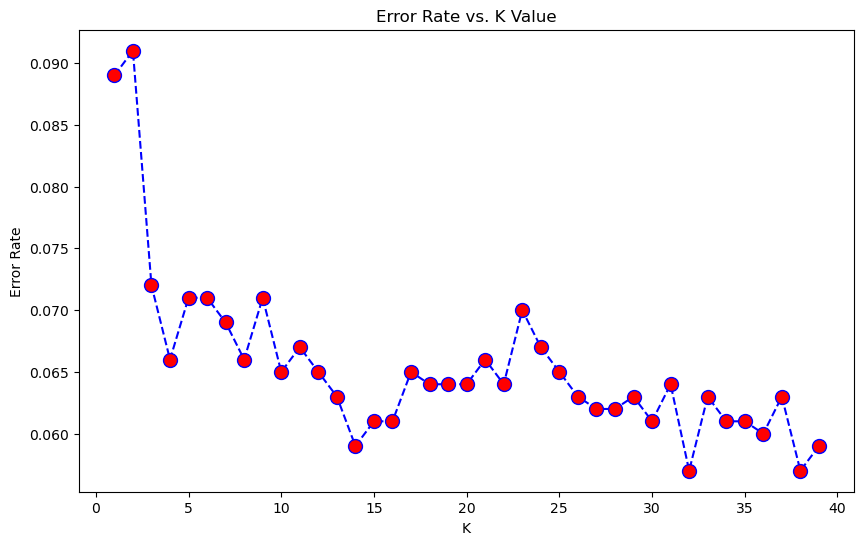

In [34]:
plt.figure(figsize=(10,6))
#plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
  #       markerfacecolor='red', markersize=10)
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

Text(0, 0.5, 'Accuracy Rate')

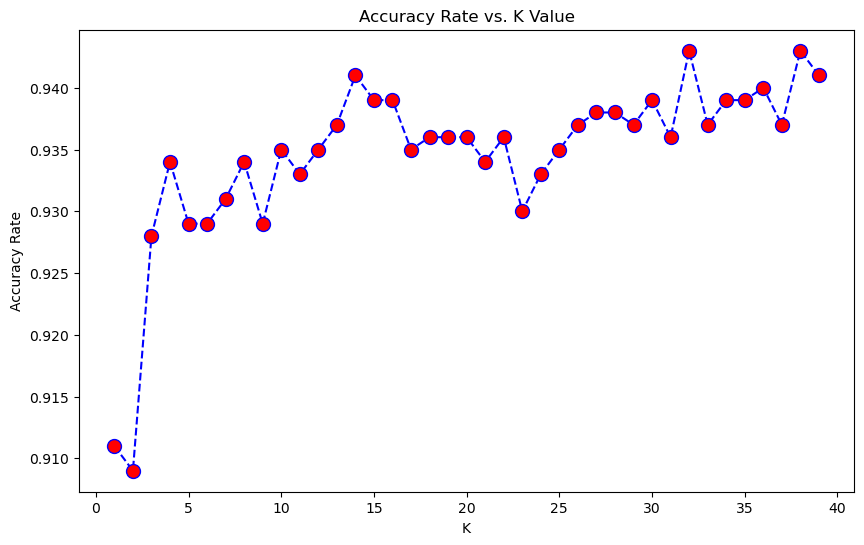

In [30]:
plt.figure(figsize=(10,6))
#plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
  #       markerfacecolor='red', markersize=10)
plt.plot(range(1,40),accuracy_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Accuracy Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy Rate')

Here we can see that that around K>23 the error rate just tends to hover around 0.06-0.05 Let's retrain the model with that and check the classification report!

In [38]:
# FIRST A QUICK COMPARISON TO OUR ORIGINAL K=1
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=1')
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

WITH K=1
[[134   8]
 [ 11 147]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       142
           1       0.95      0.93      0.94       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



In [37]:
# NOW WITH K=23
knn = KNeighborsClassifier(n_neighbors=23)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=23')
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

WITH K=23
[[135   7]
 [ 10 148]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       142
           1       0.95      0.94      0.95       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300

